# Demo of the Soft Masks

The purpose of the soft masks are to improve the rendering of the target cue and search image by smoothing the borders of the pasted cutout images pasted on the uniform gray background. 

Two different soft mask variations are implemented in `ivsn_invariance.imaging` (`alpha`, `cosine`), which are demonstrated and analysed within this notebook. 

## 1. Setup

In [62]:
import sys
import types
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

REPO_CODES = Path.cwd().parent  # codes/
if str(REPO_CODES) not in sys.path:
    sys.path.insert(0, str(REPO_CODES))

from ivsn_invariance.data import load_rgba
from ivsn_invariance.imaging import render_cue
from ivsn_invariance import runtime

DATA_ROOT = REPO_CODES / "dataset" / "coco_crops_transparent_8cat"
category_dir = DATA_ROOT / "teddybears"
sample_path = category_dir / "img_00000.png"
print(f"Using sample image: {sample_path}")

def make_args(smoothing_mode, alpha_soften_blur_radius=3.0, edge_taper_width_px=5.0):
    return types.SimpleNamespace(
        smoothing_mode=smoothing_mode,
        smooth_cue=True,
        alpha_soften_blur_radius=alpha_soften_blur_radius,
        edge_taper_width_px=edge_taper_width_px,
    )

Using sample image: /Users/nadine/Documents/Uni/Hiwi/Codebase/InvariantSearch/codes/dataset/coco_crops_transparent_8cat/teddybears/img_00000.png


## 2. Mask Visualization


### 2.1 Alpha Soft Mask (Gaussian blur on alpha channel)

Rendered cue images for the untapered cue and four `alpha_soften_blur_radius` values.

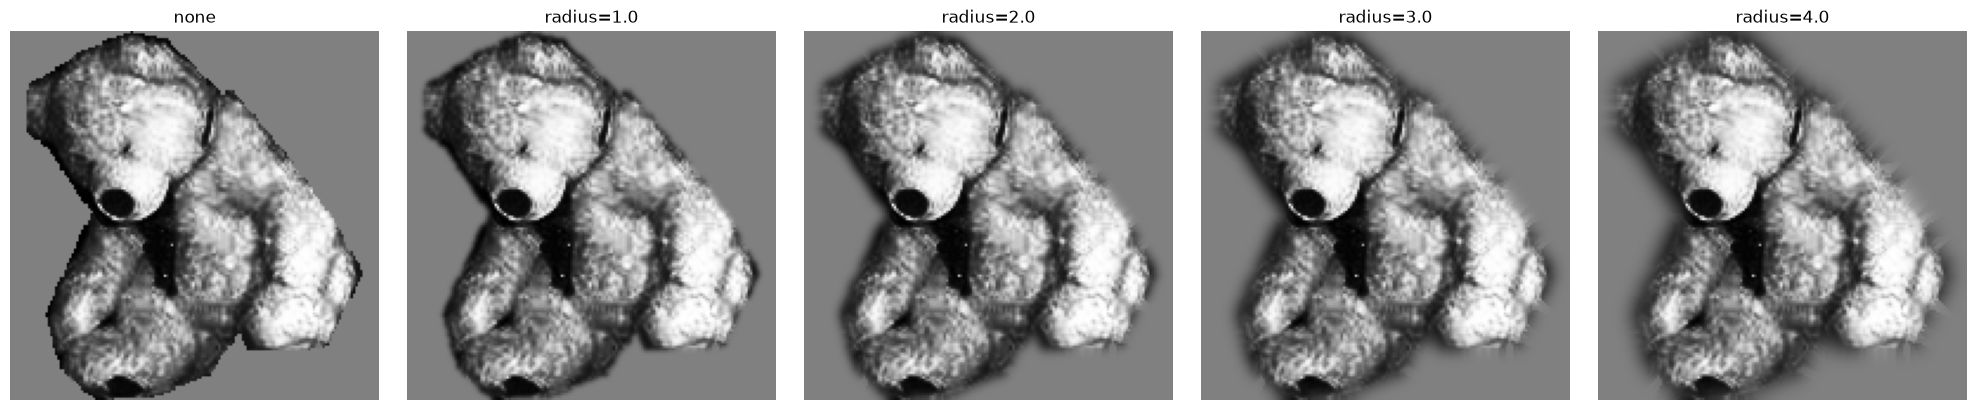

In [63]:
args_none = make_args("none")
_, cue_before = render_cue(sample_path, args_none)

blur_radii = [1.0, 2.0, 3.0, 4.0]
cue_blur_radii = {"none": cue_before}
for radius in blur_radii:
    _, cue = render_cue(sample_path, make_args("alpha", alpha_soften_blur_radius=radius))
    cue_blur_radii[f"radius={radius}"] = cue

fig, axes = plt.subplots(1, len(cue_blur_radii), figsize=(4 * len(cue_blur_radii), 4))
for ax, (label, img) in zip(axes, cue_blur_radii.items()):
    ax.imshow(img)
    ax.set_title(label)
    ax.axis("off")
plt.tight_layout()
plt.show()

cue_after_alpha = cue_blur_radii["radius=3.0"]

### 2.2 Cosine Soft Mask (boundary-following cosine taper)

Rendered cue images for the untapered cue and four `edge_taper_width_px` values.

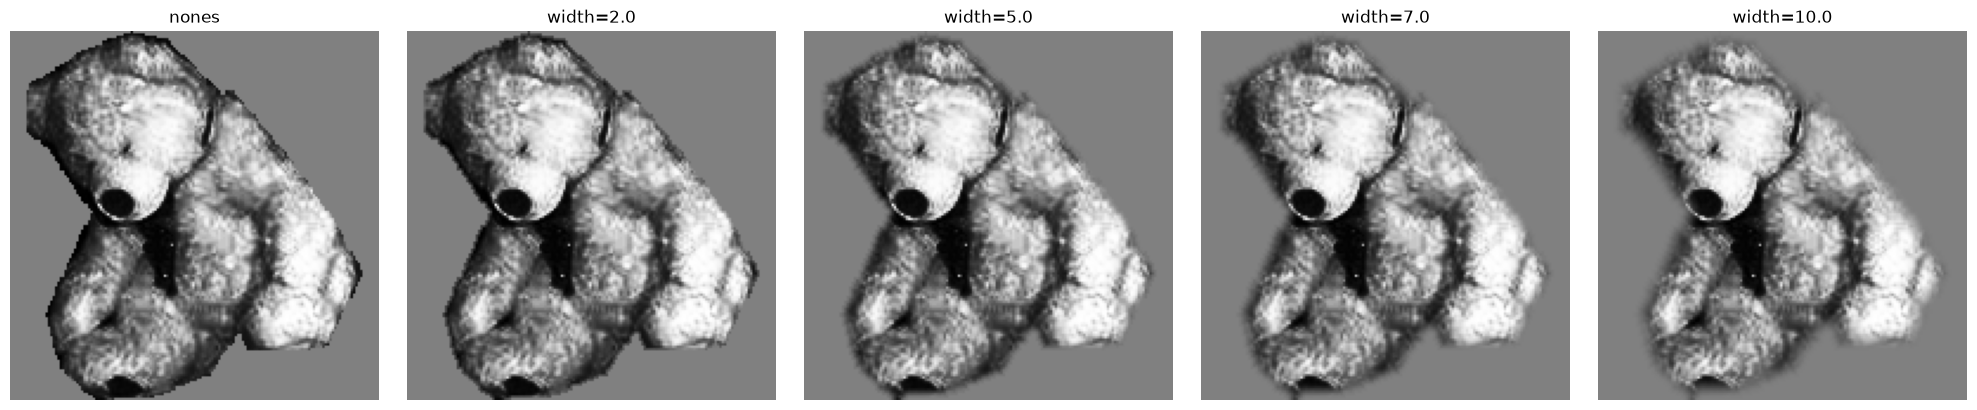

In [64]:
taper_widths = [2.0, 5.0, 7.0, 10.0]
cue_taper_widths = {"nones": cue_before}
for width in taper_widths:
    _, cue = render_cue(sample_path, make_args("cosine", edge_taper_width_px=width))
    cue_taper_widths[f"width={width}"] = cue

fig, axes = plt.subplots(1, len(cue_taper_widths), figsize=(4 * len(cue_taper_widths), 4))
for ax, (label, img) in zip(axes, cue_taper_widths.items()):
    ax.imshow(img)
    ax.set_title(label)
    ax.axis("off")
plt.tight_layout()
plt.show()

cue_after_cosine = cue_taper_widths["width=5.0"]

## 3. Image Border Analysis

To evaluate the effects of the soft masks, the pixel intensity (mean of RGB) along the middle row and middle column are visualied below. The unmodified cue should show a sharp step at the object boundary, whereas the alpha- and cosine-smoothed cues are expected to show a smoother border line.

In [65]:
def middle_row_col(img):
    arr = np.array(img, dtype=np.float32).mean(axis=2)  # mean over RGB
    mid_row = arr.shape[0] // 2
    mid_col = arr.shape[1] // 2
    return arr[mid_row, :], arr[:, mid_col]

### 3.1 Alpha Soft Mask

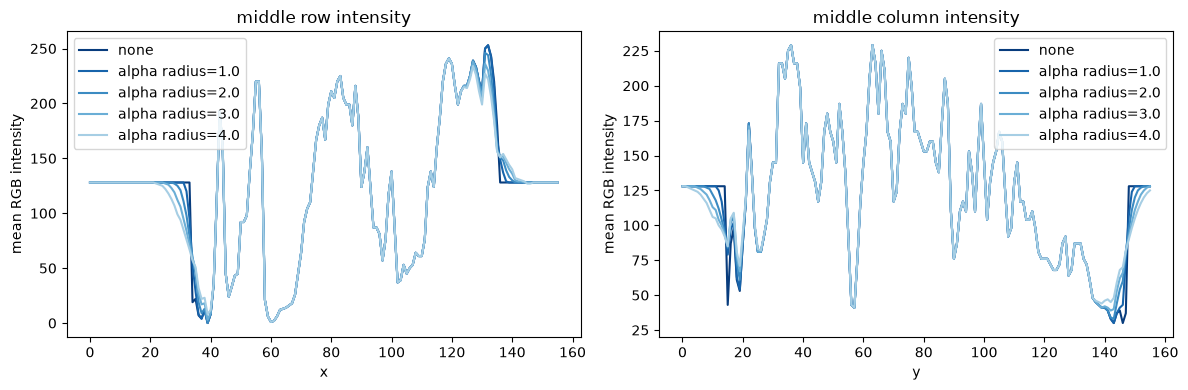

In [66]:
blur_variants = {"none": cue_before}
for radius in blur_radii:
    _, cue = render_cue(sample_path, make_args("alpha", alpha_soften_blur_radius=radius))
    blur_variants[f"alpha radius={radius}"] = cue

blues = plt.cm.Blues(np.linspace(0.95, 0.35, len(blur_variants)))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for color, (label, img) in zip(blues, blur_variants.items()):
    row, _ = middle_row_col(img)
    axes[0].plot(row, label=label, color=color)
for color, (label, img) in zip(blues, blur_variants.items()):
    _, col = middle_row_col(img)
    axes[1].plot(col, label=label, color=color)
axes[0].set_title("middle row intensity")
axes[0].set_xlabel("x")
axes[0].set_ylabel("mean RGB intensity")
axes[0].legend()
axes[1].set_title("middle column intensity")
axes[1].set_xlabel("y")
axes[1].set_ylabel("mean RGB intensity")
axes[1].legend()
plt.tight_layout()
plt.show()

### 3.2 Cosine Soft Mask

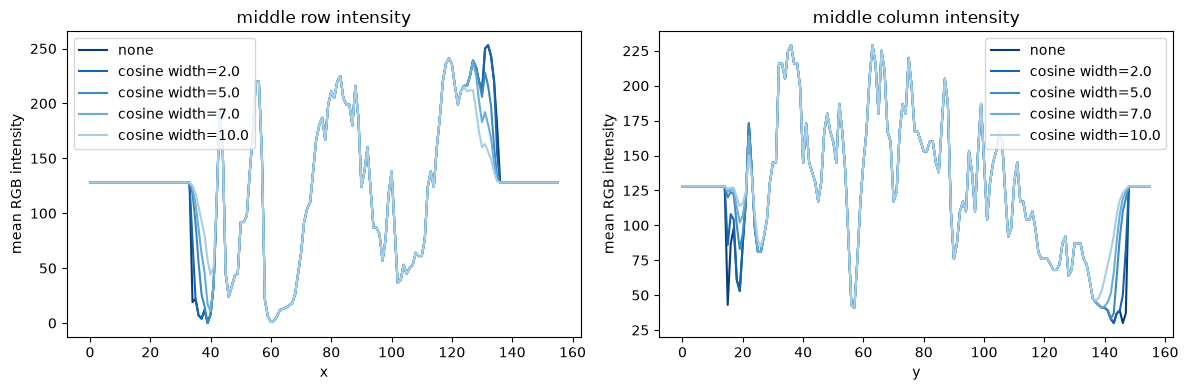

In [67]:
taper_variants = {"none": cue_before}
for width in taper_widths:
    _, cue = render_cue(sample_path, make_args("cosine", edge_taper_width_px=width))
    taper_variants[f"cosine width={width}"] = cue

blues = plt.cm.Blues(np.linspace(0.95, 0.35, len(taper_variants)))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for color, (label, img) in zip(blues, taper_variants.items()):
    row, _ = middle_row_col(img)
    axes[0].plot(row, label=label, color=color)
for color, (label, img) in zip(blues, taper_variants.items()):
    _, col = middle_row_col(img)
    axes[1].plot(col, label=label, color=color)
axes[0].set_title("middle row intensity")
axes[0].set_xlabel("x")
axes[0].set_ylabel("mean RGB intensity")
axes[0].legend()
axes[1].set_title("middle column intensity")
axes[1].set_xlabel("y")
axes[1].set_ylabel("mean RGB intensity")
axes[1].legend()
plt.tight_layout()
plt.show()

### 3.3 Direct Comparison

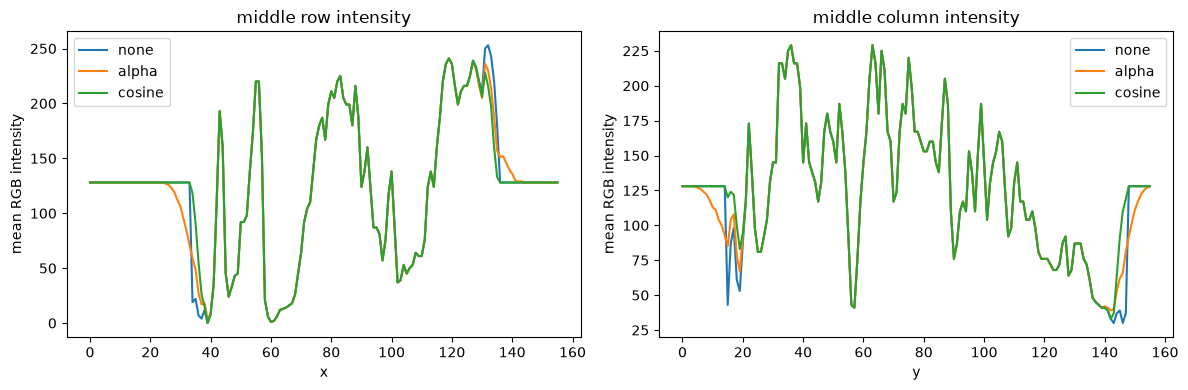

In [68]:
variants = {
    "none": cue_before,
    "alpha": blur_variants[f"alpha radius={3.0}"],
    "cosine": taper_variants[f"cosine width={5.0}"],
}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for label, img in variants.items():
    row, _ = middle_row_col(img)
    axes[0].plot(row, label=label)
for label, img in variants.items():
    _, col = middle_row_col(img)
    axes[1].plot(col, label=label)
axes[0].set_title("middle row intensity")
axes[0].set_xlabel("x")
axes[0].set_ylabel("mean RGB intensity")
axes[0].legend()
axes[1].set_title("middle column intensity")
axes[1].set_xlabel("y")
axes[1].set_ylabel("mean RGB intensity")
axes[1].legend()
plt.tight_layout()
plt.show()

## Discussion

Both masks effectively smooth the borders of the image cutout. However, the alpha soft mask extends the boundary of the cutout, resulting in a larger effective image area. In contrast, the cosine soft mask preserves the original cutout dimensions, although it produces a comparatively sharper transition at the borders.

Increasing the taper width of the cosine soft mask creates a smoother border transition, but excessive tapering may also attenuate relevant image information near the edges.

For the purposes of this project, the cosine soft mask is the more suitable choice. Since it does not extend the cutout boundaries, it simplifies the placement of adjacent images by reducing the risk of overlap while still providing sufficient border smoothing. Width values between 5.0 and 7.0 appear appropriate. 